---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 12. Convolução em Baixo Nível

Neste notebook iniciamos a exploração prática dos mecanismos fundamentais das redes convolucionais, partindo da sua base matemática: a operação de convolução.  
O objetivo é compreender, através de código NumPy puro, como um filtro percorre uma imagem, como diferentes kernels realçam padrões distintos (bordas, contornos, texturas) e de que forma a combinação de convolução, não linearidade e redução espacial constitui o alicerce das CNNs.  
A abordagem é deliberadamente de “baixo nível”, sem recorrer a frameworks de *deep learning*, permitindo visualizar cada passo e relacioná-lo com o processamento clássico de imagem.

## 12.1. Configuração inicial e função auxiliar

Antes de começarmos a construir a nossa mini-rede convolucional do zero, importamos algumas bibliotecas fundamentais de Python:

- **NumPy** – para operações numéricas sobre matrizes (as imagens serão tratadas como arrays 2D ou 3D de NumPy).  
- **Matplotlib** – para visualizar resultados intermédios, como mapas de características e filtros.  
- **SciPy (módulo signal)** – fornece implementações eficientes de convolução, que utilizaremos mais adiante para simular camadas convolucionais.

Configuramos também o Matplotlib para utilizar um formato de figura quadrado (`6 × 6` polegadas), garantindo proporções consistentes entre as imagens.

A função `show()` abaixo é uma pequena **função auxiliar de visualização** usada ao longo de todo o notebook.  
Apresenta uma imagem (`img`) em tons de cinzento por defeito e oculta os eixos para facilitar a leitura.  
Opcionalmente, aceita:
- `title`: texto que aparece acima da imagem (útil para identificar etapas como *original*, *filtrada* ou *pooling*),
- `cmap`: o nome de um mapa de cores (por exemplo, `"gray"`, `"viridis"`, `"plasma"`), que controla a forma como os valores de píxel são representados.

Nota pedagógica: é útil experimentar pequenas alterações, como modificar o mapa de cores ou o tamanho da figura, para perceber como a representação visual influencia a interpretação.  
Por exemplo, definir `plt.rcParams["figure.figsize"] = (3,3)` torna a execução mais rápida, e `"plasma"` acrescenta uma gradação cromática mais visível.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
plt.rcParams["figure.figsize"] = (3,3)

def show(img, title=None, cmap="gray"):
    plt.imshow(img, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

## 12.2. Criação de imagem sintética simples

Para testar a rede convolucional, começamos com uma **imagem artificial muito simples**, em vez de uma fotografia real.  
Desta forma, cada transformação (convolução, pooling, etc.) pode ser observada de forma clara e controlada.

1. Fixamos uma semente aleatória (`np.random.seed(0)`) para garantir reprodutibilidade.  
   Mesmo que esta imagem não envolva ruído aleatório, é boa prática definir sempre o ponto de partida.

2. Criamos uma **matriz 32×32 de zeros**, que representa uma imagem em tons de cinzento.  
   Cada valor corresponde à intensidade de um píxel entre 0 e 1.

3. Desenhamos duas barras brancas (valor = 1.0):
   - uma barra vertical nas colunas 14–18;  
   - uma barra horizontal nas linhas 14–18.  
   O resultado é uma cruz centrada na imagem.

4. Para suavizar as transições e obter um aspeto mais natural, multiplicamos toda a imagem por uma **janela Gaussiana** gerada com  
   `signal.windows.gaussian(32, std=6)`.  
   Esta janela atua como um gradiente de intensidade que decresce do centro para as margens, simulando um leve desfoque.

5. Por fim, usamos a função `show()` para visualizar o resultado e imprimimos a forma `(32, 32)` para confirmação.

Este passo demonstra que uma imagem é, essencialmente, uma matriz numérica que pode ser construída e manipulada diretamente.  
É útil experimentar:
- aumentar a resolução (por exemplo, 64×64);  
- alterar a espessura das barras (`img[10:22, 12:20]`);  
- ou modificar o desvio padrão (`std`) da Gaussiana para observar o efeito na nitidez dos contornos.

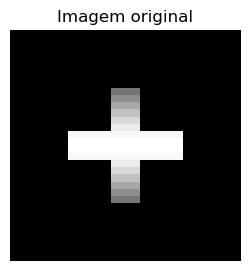

(32, 32)


In [11]:
# Criar imagem artificial simples (barras e diagonais)
np.random.seed(0)
img = np.zeros((32, 32))
img[8:24, 14:18] = 1.0             # barra vertical
img[14:18, 8:24] = 1.0             # barra horizontal
img = signal.windows.gaussian(32, std=6).reshape(32, 1) * img

show(img, "Imagem original")
print(img.shape)

## 12.3. Implementação manual da convolução 2D

Nesta célula implementamos uma função `convolve2d()` totalmente manual, que aplica um **filtro convolucional** a uma imagem 2D.

O objetivo é mostrar o que acontece internamente numa camada convolucional de uma rede neuronal, sem recorrer a frameworks como TensorFlow ou PyTorch.

### Estrutura e parâmetros

A função recebe:
- `image`: matriz 2D (grayscale) de entrada;  
- `kernel`: filtro convolucional (por exemplo, Sobel, Laplace ou Gaussiano);  
- `stride`: passo de deslocamento do kernel (por defeito `1`);  
- `padding`: número de píxeis a acrescentar em cada margem da imagem (por defeito `0`).
- `mode`: número de píxeis a acrescentar em cada margem da imagem (por defeito `0`).
  
**`mode="conv"`** → executa a **convolução matemática verdadeira**, invertendo o kernel antes da multiplicação.  
**`mode="corr"`** → executa a **correlação cruzada**, usada em frameworks de *deep learning* como PyTorch e TensorFlow.

Esta distinção é importante:
- Na definição matemática e no processamento clássico de imagem, “convolução” implica inverter o filtro.  
- Nas redes neuronais convolucionais (CNN), o termo “convolução” é usado de forma informal para designar a correlação, pois é mais eficiente computacionalmente.

### Etapas da função

1. **Padding manual**  
   Se `padding > 0`, a imagem é ampliada adicionando margens de zeros.  
   Isto permite controlar se a saída mantém ou reduz as dimensões originais.  
   (Por exemplo, `padding=1` em filtros 3×3 mantém a dimensão da imagem.)

2. **Cálculo do tamanho da saída**  
   As dimensões resultantes (`out_h`, `out_w`) são obtidas pela fórmula clássica:  
   \[
   \text{out} = \frac{(n - f)}{\text{stride}} + 1
   \]
   onde `n` é a dimensão da imagem e `f` a dimensão do filtro.

3. **Criação da matriz de saída**  
   Inicializa-se uma matriz de zeros com o tamanho calculado.

4. **Convolução propriamente dita**  
   Dois ciclos `for` percorrem a imagem, extraindo uma região (`region`) com o mesmo tamanho do kernel.  
   Cada região é multiplicada elemento a elemento pelo kernel, e a soma dos produtos (`np.sum(region * kernel)`) constitui o novo valor de saída nesse píxel.

5. **Retorno da imagem filtrada**  
   O resultado é uma nova matriz (`output`) onde cada valor representa a resposta do filtro no ponto correspondente da imagem original.

### Notas pedagógicas
- Alterar o parâmetro `stride` permite observar como o passo influencia a resolução espacial da saída.  
- Introduzir `padding` mostra como preservar dimensões é possível sem cortar bordas.  
- Este código é intencionalmente ineficiente: o foco é a clareza conceptual, não a performance.  
  Em implementações reais, esta operação é feita em lote e com convoluções vetorizadas ou FFT.

### Experiência sugerida

1. Aplicar o mesmo filtro Sobel nos dois modos:
   ```python
   sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
   edges_conv = convolve2d(img, sobel_x, padding=1, mode="conv")
   edges_corr = convolve2d(img, sobel_x, padding=1, mode="corr")

In [31]:
def convolve2d(image, kernel, stride=1, padding=0, mode="conv"):
    if mode == "conv":
        kernel = np.flipud(np.fliplr(kernel))

    # Padding manual
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode="constant")

    h, w = image.shape
    kh, kw = kernel.shape
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1
    output = np.zeros((out_h, out_w))

    # Convolução / correlação manual
    for i in range(0, out_h):
        for j in range(0, out_w):
            region = image[i*stride:i*stride+kh, j*stride:j*stride+kw]
            output[i, j] = np.sum(region * kernel)

    return output

## 12.4. Aplicação de filtros convolucionais clássicos

Agora aplicamos a função `convolve2d()` para observar como diferentes **kernels (filtros)** realçam padrões específicos na imagem.

### Filtros utilizados

1. **Sobel X**  
   \[
   \begin{bmatrix}
   -1 & 0 & 1 \\
   -2 & 0 & 2 \\
   -1 & 0 & 1
   \end{bmatrix}
   \]
   Deteta variações horizontais — realça **bordas verticais**.

2. **Sobel Y**  
   \[
   \begin{bmatrix}
    1 &  2 &  1 \\
    0 &  0 &  0 \\
   -1 & -2 & -1
   \end{bmatrix}
   \]
   Deteta variações verticais — realça **bordas horizontais**.

3. **Laplaciano**  
   \[
   \begin{bmatrix}
   0 & 1 & 0 \\
   1 & -4 & 1 \\
   0 & 1 & 0
   \end{bmatrix}
   \]
   Mede a segunda derivada da intensidade — responde a **mudanças abruptas** em qualquer direção (acentua contornos e transições fortes).

### Parâmetros e execução

Usamos `padding=1` para preservar as dimensões originais da imagem (uma vez que os filtros são 3×3).  
Cada filtro é aplicado separadamente através da função `convolve2d()`, e o resultado é visualizado com a função `show()`.

- `edges_x` → imagem filtrada com **Sobel X**  
- `edges_y` → imagem filtrada com **Sobel Y**  
- `laplace` → imagem filtrada com **Laplaciano**

### Observações didáticas

- Alterar os coeficientes dos filtros permite criar variações personalizadas (por exemplo, filtros de reforço de contraste).  
- Comparar `edges_x` e `edges_y` ajuda a compreender o conceito de **gradiente de intensidade**:  
  cada um responde apenas a variações em determinada direção.  
- A combinação dos dois (via norma Euclidiana ou soma ponderada) origina um mapa completo de arestas, uma ideia que será retomada nas camadas convolucionais de redes neurais.

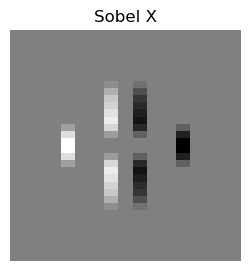

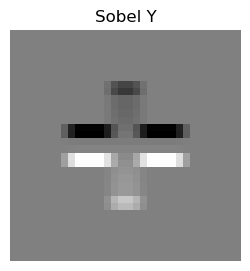

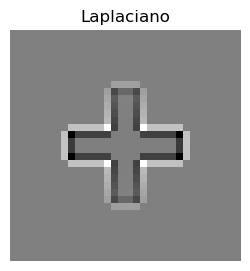

In [29]:
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
laplacian = np.array([[0,1,0],[1,-4,1],[0,1,0]])

sobel_x = sobel_x / 8
sobel_y = sobel_y / 8
laplacian = laplacian / 8

edges_x = convolve2d(img, sobel_x, padding=1)
edges_y = convolve2d(img, sobel_y, padding=1)
laplace = convolve2d(img, laplacian, padding=1)

show(edges_x, "Sobel X")
show(edges_y, "Sobel Y")
show(laplace, "Laplaciano")

## 12.5 Verificação da implementação

Depois de termos implementado a nossa própria função `convolve2d()`, é importante verificar se o resultado coincide com o de uma implementação fiável e otimizada.  
Para isso, usamos a função **`scipy.signal.convolve2d()`**, que realiza a mesma operação de forma vetorizada e muito mais eficiente.

### Procedimento

1. Aplicamos o filtro **Sobel X** à mesma imagem, agora com `signal.convolve2d(img, sobel_x, mode="same")`.  
   O argumento `mode="same"` garante que a imagem resultante tem as mesmas dimensões da entrada — tal como quando usamos `padding=1` na nossa função.

2. Calculamos a **diferença absoluta** entre as duas imagens (`edges_x` da implementação manual e `edges_scipy` da função SciPy):  
   ```python
   diff = np.abs(edges_x - edges_scipy)

Diferença média: 0.04806171449551622


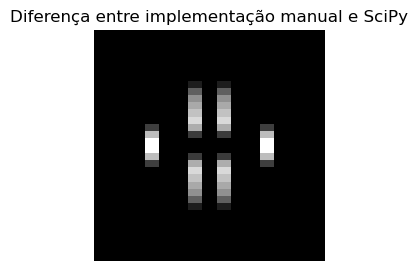

In [33]:
edges_scipy = signal.convolve2d(img, sobel_x, mode="same")
diff = np.abs(edges_x - edges_scipy)
print("Diferença média:", diff.mean())
show(diff, "Diferença entre implementação manual e SciPy")

## 12.6.Aplicação da função de ativação ReLU

Nas redes neuronais convolucionais, após cada convolução é comum aplicar uma **função de ativação não linear**.  
O objetivo é introduzir não linearidade no modelo — sem isso, a rede seria apenas uma sequência de operações lineares e não teria capacidade para representar padrões complexos.

A função **ReLU** (*Rectified Linear Unit*) é uma das mais simples e eficazes:
\[
\text{ReLU}(x) = \max(0, x)
\]

### Comportamento
- Valores positivos permanecem inalterados;  
- Valores negativos são truncados a zero.

Este comportamento tem duas vantagens:
1. **Elimina respostas negativas**, que em contextos de visão correspondem a anti-bordas ou direções opostas de gradiente;  
2. **Preserva a forma do padrão** sem introduzir compressão não linear (como no caso da sigmóide ou tanh).

### Implementação
A função é facilmente implementada em NumPy através de:
```python
def relu(x):
    return np.maximum(0, x)

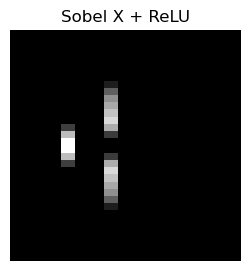

In [34]:
def relu(x):
    return np.maximum(0, x)

edges_relu = relu(edges_x)
show(edges_relu, "Sobel X + ReLU")

## 12.7. Exploração comparativa de diferentes filtros (kernels)

Depois de compreender o funcionamento interno da convolução, podemos aplicar vários **kernels** à mesma imagem e observar o efeito de cada um.  
Nesta célula definimos um pequeno dicionário de filtros clássicos, e percorremo-lo num ciclo para visualizar as respostas individuais.

### Filtros incluídos

1. **Sobel X**  
   Deteta variações horizontais → realça **bordas verticais**.  

2. **Sobel Y**  
   Deteta variações verticais → realça **bordas horizontais**.  

3. **Laplaciano**  
   Mede a segunda derivada → responde a **mudanças bruscas de intensidade** em qualquer direção (acentua contornos).  

4. **Borda diagonal**  
   Filtro criado manualmente para realçar **padrões diagonais**.  
   A sua estrutura `[2,1,0; 1,0,-1; 0,-1,-2]` é assimétrica e favorece gradientes que se orientam em diagonal descendente (do canto superior esquerdo para o inferior direito).

### Interpretação dos resultados

Cada filtro atua como um **extrator de características direcionais**:  
- O Sobel X responde a arestas verticais;  
- O Sobel Y a horizontais;  
- O Laplaciano reage a qualquer transição brusca (sem distinguir direção);  
- O filtro diagonal mostra-se sensível a inclinações específicas.

Este exercício ajuda a compreender como as **camadas iniciais de uma CNN** funcionam: cada kernel aprende a detetar padrões simples — bordas, texturas ou orientações — que servirão de base para formas mais complexas em camadas posteriores.

### Sugestões de exploração
- Experimentar outros tamanhos de kernel (5×5, 7×7) e observar o efeito na nitidez e na suavização.  
- Alterar os coeficientes do filtro diagonal para mudar a direção de sensibilidade (por exemplo, invertendo o sinal para captar a diagonal oposta).  
- Combinar os resultados de vários filtros através de soma ponderada ou da raiz quadrada da soma dos quadrados (`np.sqrt(SobelX² + SobelY²)`), simulando a magnitude do gradiente total.

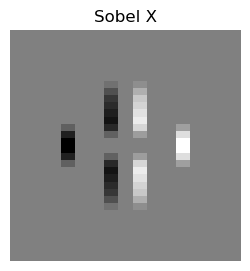

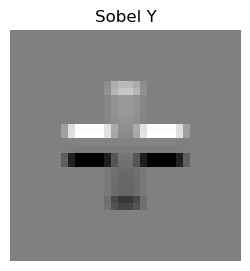

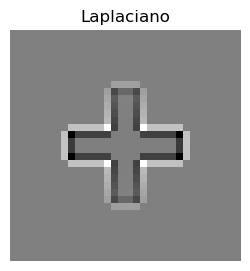

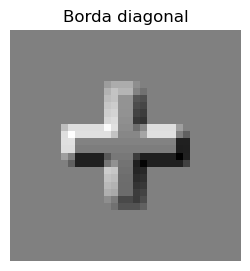

In [35]:
kernels = {
    "Sobel X": sobel_x,
    "Sobel Y": sobel_y,
    "Laplaciano": laplacian,
    "Borda diagonal": np.array([[2,1,0],[1,0,-1],[0,-1,-2]])
}

for name, k in kernels.items():
    filtered = convolve2d(img, k, padding=1)
    show(filtered, name)

## 12.8. Conclusão
A operação de convolução que implementámos é o núcleo das *Convolutional Neural Networks (CNNs)*.  
Cada filtro (kernel) aprende a reagir a padrões específicos: arestas, texturas ou formas.  
Num CNN real, os pesos dos kernels são aprendidos automaticamente pelo treino com *backpropagation*, 
em vez de serem definidos manualmente como fizemos aqui.